# (노트) 함수형 Model

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [데이터과학]

### imports

In [6]:
import tensorflow as tf
import tensorflow.experimental.numpy as tnp 
import numpy as np
import matplotlib.pyplot as plt

In [7]:
tnp.experimental_enable_numpy_behavior()

### 함수형 모델 예제1

`-` data

In [8]:
x = tnp.linspace(0,1,100).reshape(100,1)

In [9]:
tf.random.set_seed(43052)
y= x + tf.random.normal([100,1])*0.1

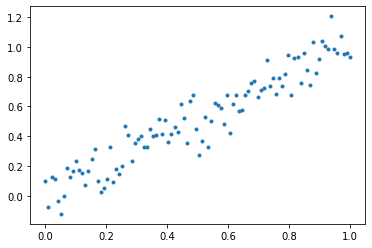

In [10]:
plt.plot(x,y,'.')

`-` Input 설정 

In [11]:
x0 = tf.keras.layers.Input(shape=(1,)) # observation을 제외한 차원

In [12]:
l1= tf.keras.layers.Dense(30)
a1= tf.keras.layers.Activation(tf.nn.relu)
l2= tf.keras.layers.Dense(50)
a2= tf.keras.layers.Activation(tf.nn.relu)
l3= tf.keras.layers.Dense(1)

In [13]:
x1 = a1(l1(x0))
x2 = a2(l2(x1))
x3 = l3(x2)

`-` input과 output설정

In [14]:
net = tf.keras.Model(inputs=x0, outputs=x3)

In [15]:
net.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 dense (Dense)               (None, 30)                60        
                                                                 
 activation (Activation)     (None, 30)                0         
                                                                 
 dense_1 (Dense)             (None, 50)                1550      
                                                                 
 activation_1 (Activation)   (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 1,661
Trainable params: 1,661
Non-trainable par

In [16]:
net.compile(optimizer='adam',loss='mse')

In [17]:
net.fit(x,y,epochs=20)

Epoch 1/20
4/4 [==============================] - 1s 1ms/step - loss: 0.2832
Epoch 2/20
4/4 [==============================] - 0s 1ms/step - loss: 0.2053
Epoch 3/20
4/4 [==============================] - 0s 1ms/step - loss: 0.1419
Epoch 4/20
4/4 [==============================] - 0s 883us/step - loss: 0.0934
Epoch 5/20
4/4 [==============================] - 0s 1ms/step - loss: 0.0555
Epoch 6/20
4/4 [==============================] - 0s 791us/step - loss: 0.0306
Epoch 7/20
4/4 [==============================] - 0s 765us/step - loss: 0.0188
Epoch 8/20
4/4 [==============================] - 0s 854us/step - loss: 0.0152
Epoch 9/20
4/4 [==============================] - 0s 1ms/step - loss: 0.0146
Epoch 10/20
4/4 [==============================] - 0s 1ms/step - loss: 0.0142
Epoch 11/20
4/4 [==============================] - 0s 938us/step - loss: 0.0136
Epoch 12/20
4/4 [==============================] - 0s 861us/step - loss: 0.0130
Epoch 13/20
4/4 [==============================] - 0s 848us/s

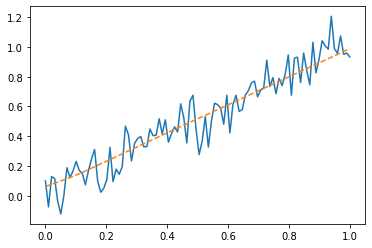

In [18]:
plt.plot(x,y)
plt.plot(x,net(x),'--')

### 함수형 모델 예제2

`-` data

In [52]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [53]:
x_train=x_train/255

In [54]:
x_train[0].shape

(28, 28)

In [55]:
x0=tf.keras.layers.Input(shape=(28,28))

In [67]:
x1=x0/255

TypeError: Cannot interpret '<KerasTensor: shape=(None, 28, 28) dtype=float32 (created by layer 'input_7')>' as a data type

In [59]:
l1=tf.keras.layers.Dense(256,activation='relu')
l2=tf.keras.layers.Dense(10,activation='softmax')

In [60]:
x2=l1(x1)
x3=l2(x2)